In [ ]:
import numpy as np
import pandas as pd

# Load feature names
features = pd.read_csv("DataSet/features.txt", sep='\s+', header=None, names=['index', 'feature_name'])
feature_names = features['feature_name'].values

# Load training data
X_train = np.loadtxt('DataSet/Train/X_train.txt')
y_train = np.loadtxt('DataSet/Train/y_train.txt').astype(int) - 1  # make labels 0-indexed
subject_train = np.loadtxt('DataSet/Train/subject_id_train.txt').astype(int)

# Load test data
X_test = np.loadtxt('DataSet/Test/X_test.txt')
y_test = np.loadtxt('DataSet/Test/y_test.txt').astype(int) - 1
subject_test = np.loadtxt('DataSet/Test/subject_id_test.txt').astype(int)

# Combine train and test
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
subject_all = np.concatenate([subject_train, subject_test])

# Create full dataframe
data = pd.DataFrame(X_all, columns=feature_names)
data['activity'] = y_all
data['subject'] = subject_all

# Save to CSV
data.to_csv("data.csv", index=False)



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
def prepare_dataset(apply_pca=False, apply_smote=False, n_components=100):
    # Step 1: Load data
    data = pd.read_csv("data.csv")
    X = data.iloc[:, :-2].values
    y = data["activity"].values

    # Step 2: Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Step 3: Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 4: Apply SMOTE (optional)
    if apply_smote:
        smote = SMOTE(random_state=42)
        X_scaled, y_encoded = smote.fit_resample(X_scaled, y_encoded)

    # Step 5: Apply PCA (optional)
    if apply_pca:
        pca = PCA(n_components=n_components)
        X_scaled = pca.fit_transform(X_scaled)

    # Step 6: Reshape to RNN input (samples, seq_len, 1)
    X_seq = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

    # Step 7: Convert to PyTorch tensors
    X_tensor = torch.tensor(X_seq, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    # Return all
    return X_tensor, y_tensor, le


In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_classes=12):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # last time step
        return self.fc(out)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

results = []

def train_and_evaluate(X_tensor, y_tensor, le, model_name=""):
    dataset = TensorDataset(X_tensor, y_tensor)
    train_size = int(0.8 * len(dataset))
    train_data, test_data = random_split(dataset, [train_size, len(dataset) - train_size])
    train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=64)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_tensor), y=y_tensor.numpy())
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    num_classes = len(le.classes_)
    model = SimpleRNN(input_size=1, hidden_size=64, num_classes=num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    for epoch in range(30):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{model_name}] Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # Evaluation
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(y_batch.tolist())
            y_pred.extend(predicted.tolist())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1 Score": f1,
        "Precision": precision,
        "Recall": recall
    })

    print(f"\n📊 [{model_name}] Classification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_.astype(str)))


[Original] Epoch 1, Loss: 278.6433
[Original] Epoch 2, Loss: 201.6713
[Original] Epoch 3, Loss: 203.4751
[Original] Epoch 4, Loss: 175.1095
[Original] Epoch 5, Loss: 162.4487
[Original] Epoch 6, Loss: 155.7086
[Original] Epoch 7, Loss: 137.6718
[Original] Epoch 8, Loss: 190.1321
[Original] Epoch 9, Loss: 333.3476
[Original] Epoch 10, Loss: 298.1440
[Original] Epoch 11, Loss: 293.5874
[Original] Epoch 12, Loss: 286.1068
[Original] Epoch 13, Loss: 280.3969
[Original] Epoch 14, Loss: 279.2014
[Original] Epoch 15, Loss: 276.5575
[Original] Epoch 16, Loss: 271.8340
[Original] Epoch 17, Loss: 271.5220
[Original] Epoch 18, Loss: 270.2883
[Original] Epoch 19, Loss: 270.4083
[Original] Epoch 20, Loss: 270.9043
[Original] Epoch 21, Loss: 273.8668
[Original] Epoch 22, Loss: 259.5596
[Original] Epoch 23, Loss: 251.3917
[Original] Epoch 24, Loss: 256.3241
[Original] Epoch 25, Loss: 275.9106
[Original] Epoch 26, Loss: 273.1058
[Original] Epoch 27, Loss: 272.3760
[Original] Epoch 28, Loss: 289.8314
[

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[PCA Only] Epoch 1, Loss: 336.5499
[PCA Only] Epoch 2, Loss: 322.0518
[PCA Only] Epoch 3, Loss: 314.1023
[PCA Only] Epoch 4, Loss: 306.5857
[PCA Only] Epoch 5, Loss: 304.3881
[PCA Only] Epoch 6, Loss: 297.2723
[PCA Only] Epoch 7, Loss: 299.2687
[PCA Only] Epoch 8, Loss: 288.1562
[PCA Only] Epoch 9, Loss: 288.4160
[PCA Only] Epoch 10, Loss: 277.1445
[PCA Only] Epoch 11, Loss: 270.6269
[PCA Only] Epoch 12, Loss: 268.7696
[PCA Only] Epoch 13, Loss: 271.8973
[PCA Only] Epoch 14, Loss: 262.2993
[PCA Only] Epoch 15, Loss: 259.3178
[PCA Only] Epoch 16, Loss: 258.5126
[PCA Only] Epoch 17, Loss: 257.8848
[PCA Only] Epoch 18, Loss: 251.3654
[PCA Only] Epoch 19, Loss: 252.5848
[PCA Only] Epoch 20, Loss: 259.9091
[PCA Only] Epoch 21, Loss: 246.0771
[PCA Only] Epoch 22, Loss: 248.6223
[PCA Only] Epoch 23, Loss: 245.1883
[PCA Only] Epoch 24, Loss: 242.3145
[PCA Only] Epoch 25, Loss: 239.0211
[PCA Only] Epoch 26, Loss: 240.6853
[PCA Only] Epoch 27, Loss: 232.6410
[PCA Only] Epoch 28, Loss: 238.8027
[

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


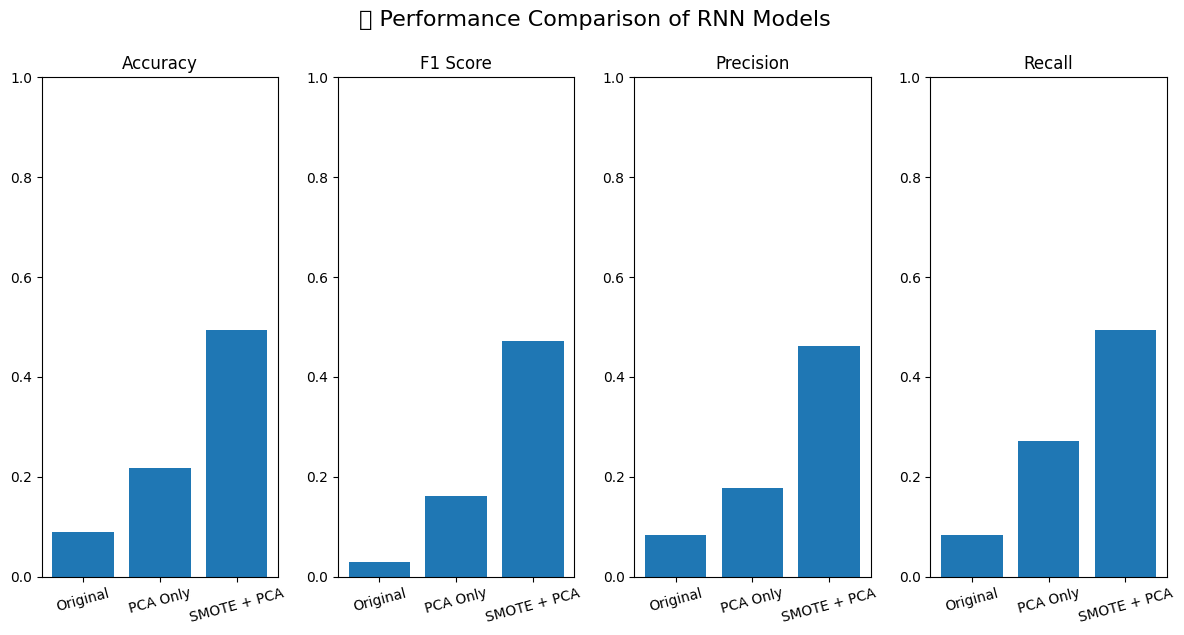

In [ ]:
# Version A
Xa, ya, lea = prepare_dataset(apply_pca=False, apply_smote=False)
train_and_evaluate(Xa, ya, lea, model_name="Original")

# Version B
Xb, yb, leb = prepare_dataset(apply_pca=True, apply_smote=False, n_components=100)
train_and_evaluate(Xb, yb, leb, model_name="PCA Only")

# Version C
Xc, yc, lec = prepare_dataset(apply_pca=True, apply_smote=True, n_components=100)
train_and_evaluate(Xc, yc, lec, model_name="SMOTE + PCA")

df_results = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
metrics = ["Accuracy", "F1 Score", "Precision", "Recall"]

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    plt.bar(df_results["Model"], df_results[metric])
    plt.title(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)

plt.tight_layout()
plt.suptitle("📊 Performance Comparison of RNN Models", fontsize=16, y=1.05)
plt.show()
